# NLP Final Project

## Do Complaint Classifiers Learn Product Semantics or Surface Shortcuts?

**Authors:** Maksim Petrenko, Timur Khairislamov  
**Course:** Natural Language Processing in Python, HSE University

### Research question

> When classifying consumer financial complaints, do classical and transformer-based NLP models learn robust product-level semantics, or do they mostly exploit surface lexical shortcuts?

### What this notebook contains

This notebook is the full reproducible experimental pipeline for the final project. It starts from data loading and task definition, then compares three models under several evaluation views:

1. **TF-IDF + Logistic Regression** as a strong classical baseline.
2. **Frozen DistilBERT embeddings + Logistic Regression** as a contextual embedding baseline without task-specific fine-tuning.
3. **Fine-tuned DistilBERT** as the main transformer model.

The project is not only about clean test accuracy. We also test robustness under product-word masking, calibration, selective prediction, retrieval support, and comparative error analysis.

### Main finding

Fine-tuned DistilBERT slightly improves clean macro-F1 over TF-IDF, but it is substantially less robust under masking of strong lexical cues. This suggests that transformer fine-tuning does not automatically solve shortcut learning in this task.


## 0. Problem statement and experimental design

**Problem.** Financial complaint triage is usually framed as product-category classification: given a complaint narrative, predict the financial product involved. A high held-out score is useful, but it is not enough for a practical system. The classifier should also be robust to wording changes, reasonably calibrated, and easy to inspect when it makes a risky prediction.

**Why shortcut learning is plausible.** The target labels are strongly associated with obvious words: *mortgage*, *credit report*, *debt*, *bank account*, *card*, and similar terms. A model can therefore score well by learning surface cues instead of more stable complaint semantics.

**Experimental plan.** We train a strong classical baseline, a frozen-transformer baseline, and a fine-tuned transformer. Then we evaluate them on:

- standard test-set accuracy and macro-F1;
- robustness after masking product cues and top TF-IDF features;
- calibration and confidence-based abstention;
- retrieval-based evidence from similar training complaints;
- concrete error cases where models disagree.

This structure directly supports the final report: each section below states its local problem before running the corresponding code.


In [1]:
# If running in a fresh environment:
# !pip install -r requirements.txt

import os
import re
import json
import math
import time
import random
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Callable, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_columns", 100)

## 1. Configuration

**Problem.** The experiment should be reproducible, but still flexible enough to run either as a full final run or as a faster debug run.

This cell defines all main settings in one place: random seed, data location, split sizes, TF-IDF parameters, transformer settings, fine-tuning hyperparameters, and output directory. The notebook first looks for a local CSV and otherwise downloads the dataset from the configured URL.


In [2]:
@dataclass
class Config:
    RANDOM_SEED: int = 42

    LOCAL_DATA_CANDIDATES: Tuple[str, ...] = (
        "consumer_complaints_small.csv",
        "../consumer_complaints_small.csv",
        "data/consumer_complaints_small.csv",
    )
    REMOTE_DATA_URL: str = (
        "https://raw.githubusercontent.com/agiccoder/nlp_mini_project/main/consumer_complaints_small.csv"
    )

    # Use None for all data. Use 500-1500 for faster iteration.
    MAX_EXAMPLES_PER_CLASS: Optional[int] = 1200

    TEST_SIZE: float = 0.15
    VAL_SIZE: float = 0.15

    TFIDF_MAX_FEATURES: int = 80_000
    TFIDF_MIN_DF: int = 2
    TFIDF_NGRAM_RANGE: Tuple[int, int] = (1, 2)

    TRANSFORMER_NAME: str = "distilbert-base-uncased"
    MAX_LENGTH: int = 256
    EMBED_BATCH_SIZE: int = 32

    RUN_FINE_TUNING: bool = True
    FT_BATCH_SIZE: int = 16
    FT_EPOCHS: int = 3
    FT_LR: float = 2e-5
    FT_WEIGHT_DECAY: float = 0.01
    FT_GRAD_CLIP: float = 1.0

    TOP_TFIDF_FEATURES_PER_CLASS_TO_MASK: int = 20
    RETRIEVAL_K: int = 5
    ARTIFACT_DIR: str = "artifacts_final"


cfg = Config()
Path(cfg.ARTIFACT_DIR).mkdir(parents=True, exist_ok=True)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch

        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    except Exception:
        pass


set_seed(cfg.RANDOM_SEED)
print(json.dumps(asdict(cfg), indent=2, default=str))

{
  "RANDOM_SEED": 42,
  "LOCAL_DATA_CANDIDATES": [
    "consumer_complaints_small.csv",
    "../consumer_complaints_small.csv",
    "data/consumer_complaints_small.csv"
  ],
  "REMOTE_DATA_URL": "https://raw.githubusercontent.com/agiccoder/nlp_mini_project/main/consumer_complaints_small.csv",
  "MAX_EXAMPLES_PER_CLASS": 1200,
  "TEST_SIZE": 0.15,
  "VAL_SIZE": 0.15,
  "TFIDF_MAX_FEATURES": 80000,
  "TFIDF_MIN_DF": 2,
  "TFIDF_NGRAM_RANGE": [
    1,
    2
  ],
  "TRANSFORMER_NAME": "distilbert-base-uncased",
  "MAX_LENGTH": 256,
  "EMBED_BATCH_SIZE": 32,
  "RUN_FINE_TUNING": true,
  "FT_BATCH_SIZE": 16,
  "FT_EPOCHS": 3,
  "FT_LR": 2e-05,
  "FT_WEIGHT_DECAY": 0.01,
  "FT_GRAD_CLIP": 1.0,
  "TOP_TFIDF_FEATURES_PER_CLASS_TO_MASK": 20,
  "RETRIEVAL_K": 5,
  "ARTIFACT_DIR": "artifacts_final"
}


## 2. Data loading and task definition

**Problem.** We need a clean supervised classification dataset with one text column and one label column. The notebook should work even if the raw file uses slightly different column names.

This section loads the complaint data, infers the text and target columns, keeps the five selected product classes, optionally caps the number of examples per class, encodes labels, and creates stratified train/validation/test splits.

The final task is:

> Input: consumer complaint narrative.  
> Output: one of five financial product classes.


In [3]:
def load_complaint_data(cfg: Config) -> pd.DataFrame:
    for p in cfg.LOCAL_DATA_CANDIDATES:
        if Path(p).exists():
            print(f"Loading local data from: {p}")
            return pd.read_csv(p)
    print("Local data not found. Loading from GitHub raw URL.")
    return pd.read_csv(cfg.REMOTE_DATA_URL)


raw_df = load_complaint_data(cfg)
print(raw_df.shape)
raw_df.head()

Local data not found. Loading from GitHub raw URL.
(20000, 3)


,consumer_complaint_narrative,product,issue
0,I have sent several requests to Experian requesting an investigation of my accounts. It has been months and I still have not received a response to my concerns. The only thing ...,Credit reporting,Credit reporting company's investigation
1,I have an account with XXXX XXXX and use their Bill Pay service. I erroneously mistypee a payment to my XXXX account instead of my Mortgage account. I called XXXX upon discover...,Bank account or service,"Making/receiving payments, sending money"
2,"I had bankruptcy about XXXX years ago, Equifax reported this account for XXXX yearswhile the other XXXX reported for XXXX years, Now I have applied for a loan. \nwith XXXX XXXX...",Credit reporting,Incorrect information on credit report
3,"I had an online savings account with Discover Bank and logged on XXXX time in XXXX, 2015 and could not access my accounts. No one could tell me what was going on with my accoun...",Bank account or service,"Making/receiving payments, sending money"
4,"They claim they are from a clerks office with legal documents, for me, and want to take me to court. i asked to speak to speak with a supervisor. I was transfered to XXXX today...",Debt collection,False statements or representation


In [4]:
def infer_text_and_label_columns(df: pd.DataFrame) -> Tuple[str, str]:
    lower_to_original = {c.lower().strip(): c for c in df.columns}

    text_candidates = [
        "consumer complaint narrative",
        "complaint narrative",
        "narrative",
        "text",
        "complaint_text",
        "complaint",
        "x",
    ]
    label_candidates = ["product", "label", "target", "category", "y"]

    text_col = None
    label_col = None

    for cand in text_candidates:
        if cand in lower_to_original:
            text_col = lower_to_original[cand]
            break
    for cand in label_candidates:
        if cand in lower_to_original:
            label_col = lower_to_original[cand]
            break

    if text_col is None:
        object_cols = [c for c in df.columns if df[c].dtype == "object"]
        avg_lens = {c: df[c].dropna().astype(str).str.len().mean() for c in object_cols}
        text_col = max(avg_lens, key=avg_lens.get)

    if label_col is None:
        object_cols = [
            c for c in df.columns if c != text_col and df[c].dtype == "object"
        ]
        candidate_cards = {c: df[c].nunique(dropna=True) for c in object_cols}
        plausible = {c: k for c, k in candidate_cards.items() if 2 <= k <= 30}
        if not plausible:
            raise ValueError(
                "Could not infer label column. Set text_col and label_col manually."
            )
        label_col = min(plausible, key=plausible.get)

    return text_col, label_col


text_col, label_col = infer_text_and_label_columns(raw_df)
print("Text column:", text_col)
print("Label column:", label_col)
print("Columns:", raw_df.columns.tolist())

Text column: consumer_complaint_narrative
Label column: product
Columns: ['consumer_complaint_narrative', 'product', 'issue']


In [5]:
df = raw_df[[text_col, label_col]].copy()
df.columns = ["text", "label"]
df["text"] = df["text"].astype(str).str.strip()
df["label"] = df["label"].astype(str).str.strip()
df = df[(df["text"].str.len() > 0) & (df["label"].str.len() > 0)].drop_duplicates(
    subset=["text", "label"]
)

preferred_classes = [
    "Credit reporting",
    "Bank account or service",
    "Debt collection",
    "Mortgage",
    "Credit card",
]
present_preferred = [c for c in preferred_classes if c in set(df["label"])]
classes_to_use = (
    present_preferred
    if len(present_preferred) >= 3
    else df["label"].value_counts().head(5).index.tolist()
)
df = df[df["label"].isin(classes_to_use)].copy()

if cfg.MAX_EXAMPLES_PER_CLASS is not None:
    df = (
        df.groupby("label", group_keys=False)
        .apply(
            lambda x: x.sample(
                min(len(x), cfg.MAX_EXAMPLES_PER_CLASS), random_state=cfg.RANDOM_SEED
            )
        )
        .reset_index(drop=True)
    )

df = df.sample(frac=1.0, random_state=cfg.RANDOM_SEED).reset_index(drop=True)
print("Prepared shape:", df.shape)
display(df["label"].value_counts().to_frame("count"))
df.head()

Prepared shape: (6000, 2)


,count
label,
Credit card,1200
Debt collection,1200
Bank account or service,1200
Mortgage,1200
Credit reporting,1200


,text,label
0,I have a US Bank secured credit card with a credit limit of {$1000.00}. I accidently overpaid the credit card which was fine and that created a credit balance on the card. The ...,Credit card
1,"On XXXX XXXX, 2015 I received an initial letter from National Credit Adjusters claiming that I owe {$1700.00} XXXX. The notice violates the FDCPA section 809",Debt collection
2,"Duplicate payment was made for an auto loan. I contested this duplicate payment at local branch and 2 days later when using my debit card, it was declined twice. I learned from...",Bank account or service
3,"I have a credit card with Bank of America for more than five years ago, when I started to use the card, my minimum payment was approximately {$80.00} now, every time that I use...",Credit card
4,To Whom it may Concern: I have submitted numerous complaints to this agency regarding the awful practices of Chase Home Financial - a company that is refusing to accurately rep...,Mortgage


In [6]:
le = LabelEncoder()
df["label_id"] = le.fit_transform(df["label"])
id_to_label = {i: label for i, label in enumerate(le.classes_)}
label_to_id = {label: i for i, label in id_to_label.items()}

train_df, temp_df = train_test_split(
    df,
    test_size=cfg.TEST_SIZE + cfg.VAL_SIZE,
    random_state=cfg.RANDOM_SEED,
    stratify=df["label_id"],
)
relative_test_size = cfg.TEST_SIZE / (cfg.TEST_SIZE + cfg.VAL_SIZE)
val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_size,
    random_state=cfg.RANDOM_SEED,
    stratify=temp_df["label_id"],
)

train_texts = train_df["text"].tolist()
val_texts = val_df["text"].tolist()
test_texts = test_df["text"].tolist()
y_train = train_df["label_id"].values
y_val = val_df["label_id"].values
y_test = test_df["label_id"].values
n_classes = len(le.classes_)

for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, part.shape, part["label"].value_counts().sort_index().to_dict())
print("Classes:", id_to_label)

train (4200, 3) {'Bank account or service': 840, 'Credit card': 840, 'Credit reporting': 840, 'Debt collection': 840, 'Mortgage': 840}
val (900, 3) {'Bank account or service': 180, 'Credit card': 180, 'Credit reporting': 180, 'Debt collection': 180, 'Mortgage': 180}
test (900, 3) {'Bank account or service': 180, 'Credit card': 180, 'Credit reporting': 180, 'Debt collection': 180, 'Mortgage': 180}
Classes: {0: 'Bank account or service', 1: 'Credit card', 2: 'Credit reporting', 3: 'Debt collection', 4: 'Mortgage'}


## 3. Exploratory analysis: why shortcut learning is plausible

**Problem.** Before training stronger models, we should check whether the task contains obvious label-specific words. If it does, clean accuracy alone may overstate how much the model understands.

This section examines class balance, text length, and top lexical features. The goal is not to do a large EDA, but to motivate the robustness tests used later.


n_chars                   n_tokens                
                           mean  median min   max     mean median min  max
label                                                                     
Bank account or service  1236.3   944.0   9  4008    229.4  174.0   1  825
Credit card              1127.0   891.5  14  3973    208.1  166.0   2  789
Credit reporting          769.1   521.0  14  3883    138.2   93.5   3  765
Debt collection           799.1   541.0   8  3944    147.7  100.0   2  814
Mortgage                 1417.8  1058.0  49  3974    257.9  197.0   6  792

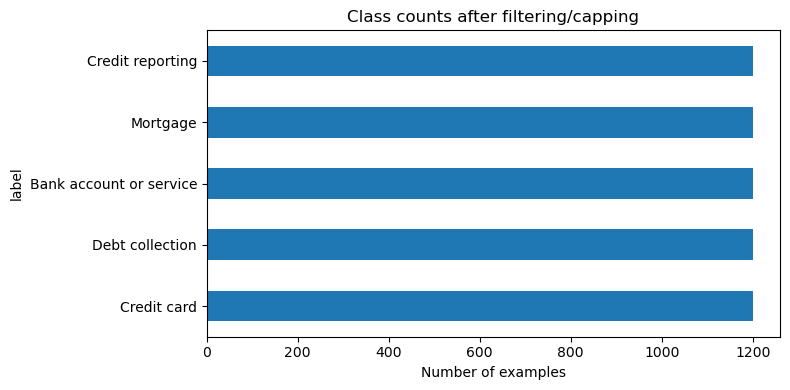

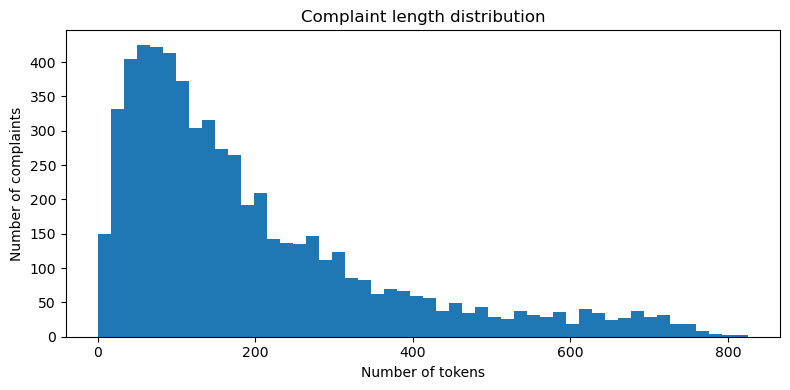

In [7]:
def simple_token_count(s: str) -> int:
    return len(re.findall(r"\b\w+\b", str(s).lower()))


df["n_chars"] = df["text"].str.len()
df["n_tokens"] = df["text"].apply(simple_token_count)
display(
    df.groupby("label")[["n_chars", "n_tokens"]]
    .agg(["mean", "median", "min", "max"])
    .round(1)
)

plt.figure(figsize=(8, 4))
df["label"].value_counts().sort_values().plot(kind="barh")
plt.title("Class counts after filtering/capping")
plt.xlabel("Number of examples")
plt.tight_layout()
plt.savefig(Path(cfg.ARTIFACT_DIR) / "class_counts.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df["n_tokens"], bins=50)
plt.title("Complaint length distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Number of complaints")
plt.tight_layout()
plt.savefig(Path(cfg.ARTIFACT_DIR) / "text_length_distribution.png", dpi=200)
plt.show()

In [8]:
eda_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=30_000,
    sublinear_tf=True,
)
X_eda = eda_vectorizer.fit_transform(df["text"])
feature_names = np.array(eda_vectorizer.get_feature_names_out())

top_features_by_class = {}
rows = []
for class_id, class_name in id_to_label.items():
    mask = df["label_id"].values == class_id
    class_mean = np.asarray(X_eda[mask].mean(axis=0)).ravel()
    rest_mean = np.asarray(X_eda[~mask].mean(axis=0)).ravel()
    scores = class_mean - rest_mean
    top_idx = scores.argsort()[::-1][:25]
    feats = feature_names[top_idx].tolist()
    top_features_by_class[class_name] = feats
    for rank, idx in enumerate(top_idx, 1):
        rows.append(
            {
                "class": class_name,
                "rank": rank,
                "feature": feature_names[idx],
                "score": scores[idx],
            }
        )

top_features_df = pd.DataFrame(rows)
top_features_df.to_csv(
    Path(cfg.ARTIFACT_DIR) / "eda_top_lexical_features_by_class.csv", index=False
)
display(top_features_df.head(40))

,class,rank,feature,score
0,Bank account or service,1,bank,0.038691
1,Bank account or service,2,account,0.027889
2,Bank account or service,3,overdraft,0.020134
3,Bank account or service,4,checking,0.019970
4,Bank account or service,5,funds,0.019792
5,Bank account or service,6,money,0.019605
6,Bank account or service,7,deposit,0.018776
7,Bank account or service,8,check,0.018345
8,Bank account or service,9,checking account,0.016784
9,Bank account or service,10,branch,0.016230


In [9]:
cue_groups = {
    "Credit reporting": [
        "credit report",
        "credit reporting",
        "experian",
        "equifax",
        "transunion",
        "dispute",
    ],
    "Debt collection": ["debt", "collector", "collection", "collect"],
    "Mortgage": ["mortgage", "escrow", "foreclosure", "loan modification"],
    "Credit card": ["credit card", "card", "billing", "apr"],
    "Bank account or service": [
        "bank account",
        "checking",
        "savings",
        "deposit",
        "overdraft",
    ],
}


def count_cue_groups(text: str) -> int:
    t = text.lower()
    return sum(any(cue in t for cue in cues) for cues in cue_groups.values())


ambiguous_df = df.copy()
ambiguous_df["cue_group_count"] = ambiguous_df["text"].apply(count_cue_groups)
display(
    ambiguous_df.sort_values("cue_group_count", ascending=False)[
        ["label", "cue_group_count", "text"]
    ].head(10)
)

,label,cue_group_count,text
2863,Credit card,5,I had a credit card with Wells Fargo. I previously owed XXXX $ on it. I paid that off a few months ago. I thought I had paid off the entire debt but apparently owed XXXX $ in i...
688,Credit reporting,5,"A compliant was filed on XXXX/XXXX/XXXX with this agency, # XXXX. Experian stated it would mail me a copy of my credit report. To date, I have NOT received the copy. This is th..."
1529,Credit reporting,5,I contacted XXXX XXXX XXXX for reporting late payments for an account during a period which they were not the loan servicer and for reporting late payments on discharged debt. ...
929,Credit card,5,I began contacting Discover Card for an account I had XX/XX/XXXX. I had filed bankruptcy in prior years and came to learn three years later that Discover Card ( amongst others ...
2643,Bank account or service,5,In XXXX I was a victim of Citizens bank 's aggressive and unfair overdraft practices. For the past 6 years I have tried to resolve this harm. Rather than resolve this harm Citi...
4307,Bank account or service,4,I have been attempting to resolve a dispute with US Bank directly and via third party mediation for consumer protections because US Bank to this date has generated fraud with a...
2453,Bank account or service,4,"After numerous troubles with fraudulent charges, unjust service charges, poor customer service and policies that change to suit the bank, we decided to bank elsewhere. In tryin..."
1854,Credit reporting,4,There are XXXX copies of my credit bureaus showing different deletion dates for the same account. I claim that the trade line payment history has been cut off purposely for the...
2440,Credit reporting,4,"I contacted by XXXX XXXX regarding an XXXX account balance that I disputed with XXXX, this past XXXX 2015. I had previously made a partial payment to RGE days before I was cont..."
3612,Mortgage,4,I never received assistance or information regarding the Chase RMBS settlement or any resources the settlement entitles me as a struggling homeowner. \nI have been denied a loa...


## 4. Shared evaluation utilities

**Problem.** All models must be evaluated in exactly the same way. Otherwise, differences in metrics could come from evaluation code rather than real model behavior.

The utilities below compute accuracy, macro-F1, weighted-F1, mean confidence, classification reports, confusion matrices, and reusable probability-based predictions. Macro-F1 is the main score because each product class should matter equally.


In [10]:
def evaluate_predictions(
    y_true, y_pred, y_proba=None, model_name="model", split_name="test"
):
    out = {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }
    if y_proba is not None:
        out["mean_confidence"] = float(np.max(y_proba, axis=1).mean())
    return out


def print_report(y_true, y_pred, title):
    print("=" * 100)
    print(title)
    print("=" * 100)
    print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))


def plot_confusion(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(n_classes))
    ax.set_yticks(range(n_classes))
    ax.set_xticklabels(le.classes_, rotation=45, ha="right")
    ax.set_yticklabels(le.classes_)
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(Path(cfg.ARTIFACT_DIR) / filename, dpi=200)
    plt.show()


def softmax_np(logits):
    logits = np.asarray(logits)
    logits = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / exp.sum(axis=1, keepdims=True)


all_results = []
model_registry = {}

## 5. Model 1: TF-IDF + Logistic Regression

**Problem.** We need a strong and interpretable classical baseline. Without it, any transformer result is hard to judge.

This model represents each complaint using word unigram and bigram TF-IDF features, then trains multinomial Logistic Regression. It is simple, fast, and especially useful for diagnosing shortcuts because its strongest coefficients correspond to readable lexical cues.


TF-IDF + LR trained in 5.1s


,model,split,accuracy,macro_f1,weighted_f1,mean_confidence
0,TF-IDF + Logistic Regression,test,0.847778,0.847883,0.847883,0.760712


TF-IDF + Logistic Regression — test set
                         precision    recall  f1-score   support

Bank account or service     0.8689    0.8833    0.8760       180
            Credit card     0.8314    0.7944    0.8125       180
       Credit reporting     0.8128    0.8444    0.8283       180
        Debt collection     0.7912    0.8000    0.7956       180
               Mortgage     0.9375    0.9167    0.9270       180

               accuracy                         0.8478       900
              macro avg     0.8484    0.8478    0.8479       900
           weighted avg     0.8484    0.8478    0.8479       900



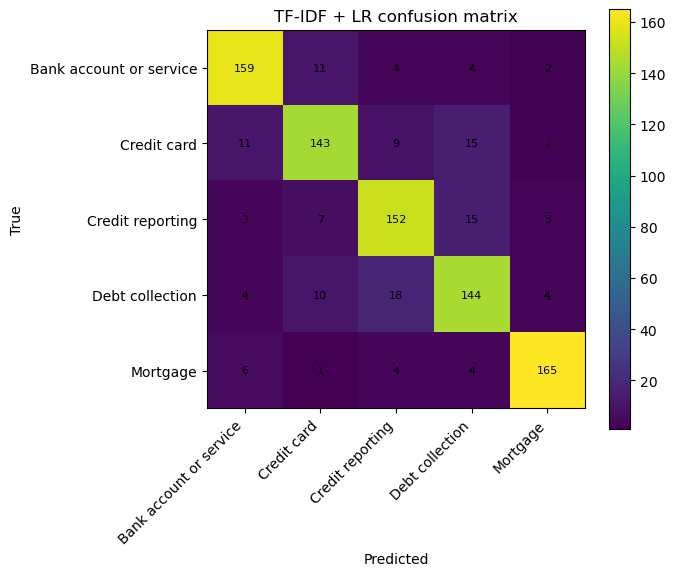

In [11]:
tfidf_lr = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                ngram_range=cfg.TFIDF_NGRAM_RANGE,
                min_df=cfg.TFIDF_MIN_DF,
                max_features=cfg.TFIDF_MAX_FEATURES,
                sublinear_tf=True,
            ),
        ),
        (
            "clf",
            LogisticRegression(
                max_iter=3000,
                C=4.0,
                class_weight="balanced",
                solver="lbfgs",
                multi_class="auto",
                n_jobs=-1,
                random_state=cfg.RANDOM_SEED,
            ),
        ),
    ]
)

start = time.time()
tfidf_lr.fit(train_texts, y_train)
print(f"TF-IDF + LR trained in {time.time() - start:.1f}s")

tfidf_test_proba = tfidf_lr.predict_proba(test_texts)
tfidf_test_pred = tfidf_test_proba.argmax(axis=1)
res = evaluate_predictions(
    y_test, tfidf_test_pred, tfidf_test_proba, "TF-IDF + Logistic Regression", "test"
)
all_results.append(res)
display(pd.DataFrame([res]))

print_report(y_test, tfidf_test_pred, "TF-IDF + Logistic Regression — test set")
plot_confusion(
    y_test, tfidf_test_pred, "TF-IDF + LR confusion matrix", "confusion_tfidf_lr.png"
)

model_registry["TF-IDF + LR"] = {
    "predict_proba": lambda texts: tfidf_lr.predict_proba(list(texts)),
    "predict": lambda texts: tfidf_lr.predict(list(texts)),
}

In [12]:
tfidf_vec = tfidf_lr.named_steps["tfidf"]
lr_clf = tfidf_lr.named_steps["clf"]
feature_names = np.array(tfidf_vec.get_feature_names_out())

lr_top_rows = []
for class_id, class_name in id_to_label.items():
    coef = lr_clf.coef_[class_id]
    top_pos = np.argsort(coef)[::-1][:30]
    for rank, idx in enumerate(top_pos, start=1):
        lr_top_rows.append(
            {
                "class": class_name,
                "rank": rank,
                "feature": feature_names[idx],
                "coefficient": coef[idx],
            }
        )

lr_top_features_df = pd.DataFrame(lr_top_rows)
lr_top_features_df.to_csv(
    Path(cfg.ARTIFACT_DIR) / "tfidf_lr_top_features_by_class.csv", index=False
)
display(lr_top_features_df.head(60))

,class,rank,feature,coefficient
0,Bank account or service,1,bank,8.584143
1,Bank account or service,2,money,4.296637
2,Bank account or service,3,branch,4.228672
3,Bank account or service,4,funds,3.979029
4,Bank account or service,5,deposit,3.901240
5,Bank account or service,6,overdraft,3.848620
6,Bank account or service,7,checking,3.836130
7,Bank account or service,8,debit,3.385695
8,Bank account or service,9,check,3.322048
9,Bank account or service,10,debit card,3.252704


## 6. Model 2: Frozen DistilBERT embeddings + Logistic Regression

**Problem.** We want to separate two questions: whether contextual representations help at all, and whether task-specific fine-tuning is necessary.

Here DistilBERT is used only as a fixed feature extractor. We mean-pool the last hidden states into sentence vectors and train Logistic Regression on top. If this model performs well, generic contextual embeddings are enough; if it performs poorly, fine-tuning is likely important.


In [13]:
try:
    import torch
    from torch.utils.data import Dataset, DataLoader
    from transformers import (
        AutoTokenizer,
        AutoModel,
        AutoModelForSequenceClassification,
    )
    from transformers import get_linear_schedule_with_warmup

    TRANSFORMERS_AVAILABLE = True
    device = torch.device("cuda" if torch.cuda.is_available() else "mps")
    print("Transformers available. Device:", device)
except Exception as e:
    TRANSFORMERS_AVAILABLE = False
    device = None
    print("Transformers are not available. Transformer sections will be skipped.")
    print(repr(e))

Transformers available. Device: mps


In [14]:
def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = (last_hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts


def embed_texts_with_transformer(
    texts,
    model_name=cfg.TRANSFORMER_NAME,
    batch_size=cfg.EMBED_BATCH_SIZE,
    max_length=cfg.MAX_LENGTH,
):
    if not TRANSFORMERS_AVAILABLE:
        raise RuntimeError("transformers/torch are not installed.")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    backbone = AutoModel.from_pretrained(model_name).to(device)
    backbone.eval()
    all_embs = []
    with torch.no_grad():
        for start_idx in range(0, len(texts), batch_size):
            batch_texts = list(texts)[start_idx : start_idx + batch_size]
            enc = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt",
            )
            enc = {k: v.to(device) for k, v in enc.items()}
            out = backbone(**enc)
            emb = mean_pool(out.last_hidden_state, enc["attention_mask"])
            all_embs.append(emb.cpu().numpy())
    return np.vstack(all_embs)


if TRANSFORMERS_AVAILABLE:
    start = time.time()
    train_emb = embed_texts_with_transformer(train_texts)
    val_emb = embed_texts_with_transformer(val_texts)
    test_emb = embed_texts_with_transformer(test_texts)
    print("Embedding shapes:", train_emb.shape, val_emb.shape, test_emb.shape)
    print(f"Embedding extraction took {time.time() - start:.1f}s")
else:
    train_emb = val_emb = test_emb = None

W0510 21:45:33.019000 94863 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Embedding shapes: (4200, 768) (900, 768) (900, 768)
Embedding extraction took 71.3s


,model,split,accuracy,macro_f1,weighted_f1,mean_confidence
0,Frozen DistilBERT emb + LR,test,0.724444,0.725724,0.725724,0.931769


Frozen DistilBERT embeddings + Logistic Regression — test set
                         precision    recall  f1-score   support

Bank account or service     0.7178    0.8056    0.7592       180
            Credit card     0.6250    0.6667    0.6452       180
       Credit reporting     0.7278    0.7278    0.7278       180
        Debt collection     0.6842    0.6500    0.6667       180
               Mortgage     0.8968    0.7722    0.8299       180

               accuracy                         0.7244       900
              macro avg     0.7303    0.7244    0.7257       900
           weighted avg     0.7303    0.7244    0.7257       900



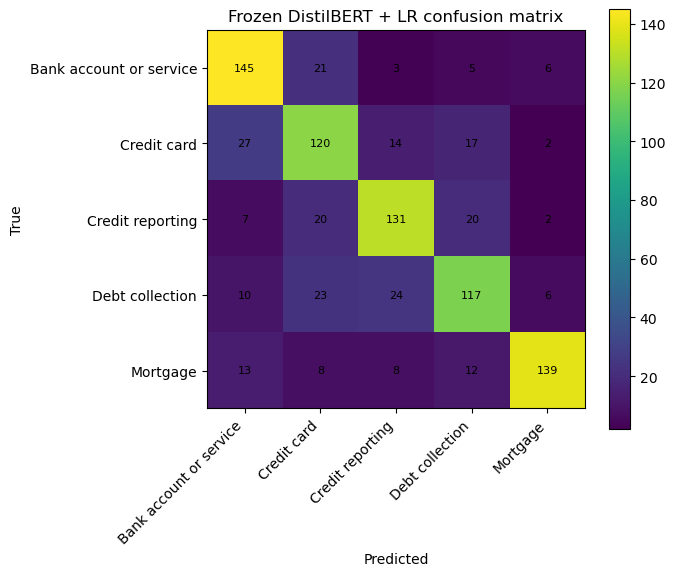

In [15]:
if TRANSFORMERS_AVAILABLE:
    frozen_bert_lr = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=3000,
                    C=2.0,
                    class_weight="balanced",
                    solver="lbfgs",
                    multi_class="auto",
                    n_jobs=-1,
                    random_state=cfg.RANDOM_SEED,
                ),
            ),
        ]
    )
    frozen_bert_lr.fit(train_emb, y_train)
    frozen_test_proba = frozen_bert_lr.predict_proba(test_emb)
    frozen_test_pred = frozen_test_proba.argmax(axis=1)
    res = evaluate_predictions(
        y_test,
        frozen_test_pred,
        frozen_test_proba,
        "Frozen DistilBERT emb + LR",
        "test",
    )
    all_results.append(res)
    display(pd.DataFrame([res]))
    print_report(
        y_test,
        frozen_test_pred,
        "Frozen DistilBERT embeddings + Logistic Regression — test set",
    )
    plot_confusion(
        y_test,
        frozen_test_pred,
        "Frozen DistilBERT + LR confusion matrix",
        "confusion_frozen_distilbert_lr.png",
    )

    def frozen_bert_predict_proba(texts):
        emb = embed_texts_with_transformer(list(texts))
        return frozen_bert_lr.predict_proba(emb)

    model_registry["Frozen DistilBERT + LR"] = {
        "predict_proba": frozen_bert_predict_proba,
        "predict": lambda texts: frozen_bert_predict_proba(texts).argmax(axis=1),
    }
else:
    print("Skipping frozen DistilBERT section.")

## 7. Model 3: Fine-tuned DistilBERT

**Problem.** This is the main neural model. It should be compared not only by clean performance, but also by robustness, calibration, and error behavior.

The model is `distilbert-base-uncased` with a classification head. It is fine-tuned on the training split and selected using validation macro-F1. The code keeps the training loop explicit so that losses, validation metrics, and saved artifacts are easy to inspect.


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'epoch': 1, 'train_loss': 0.9326701994857861, 'val_accuracy': 0.8255555555555556, 'val_macro_f1': 0.8245911648853076}
{'epoch': 2, 'train_loss': 0.42392803343303304, 'val_accuracy': 0.8533333333333334, 'val_macro_f1': 0.852871734497638}
{'epoch': 3, 'train_loss': 0.29425696051279404, 'val_accuracy': 0.8622222222222222, 'val_macro_f1': 0.8617080115686839}


,epoch,train_loss,val_accuracy,val_macro_f1
0,1,0.932670,0.825556,0.824591
1,2,0.423928,0.853333,0.852872
2,3,0.294257,0.862222,0.861708


,model,split,accuracy,macro_f1,weighted_f1,mean_confidence
0,Fine-tuned DistilBERT,test,0.851111,0.850699,0.850699,0.894473


Fine-tuned DistilBERT — test set
                         precision    recall  f1-score   support

Bank account or service     0.8580    0.8389    0.8483       180
            Credit card     0.8111    0.8111    0.8111       180
       Credit reporting     0.8308    0.9000    0.8640       180
        Debt collection     0.8284    0.7778    0.8023       180
               Mortgage     0.9278    0.9278    0.9278       180

               accuracy                         0.8511       900
              macro avg     0.8512    0.8511    0.8507       900
           weighted avg     0.8512    0.8511    0.8507       900



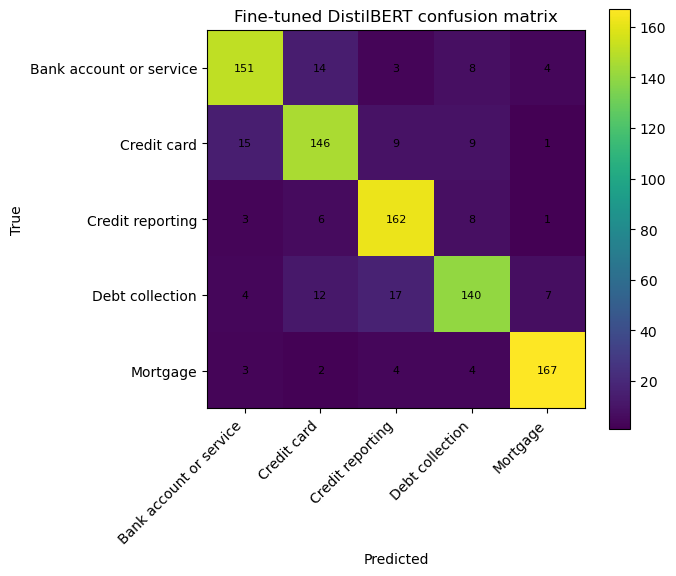

In [16]:
if TRANSFORMERS_AVAILABLE:

    class ComplaintDataset(Dataset):
        def __init__(self, texts, labels, tokenizer, max_length):
            self.texts = list(texts)
            self.labels = None if labels is None else np.asarray(labels)
            self.tokenizer = tokenizer
            self.max_length = max_length

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            enc = self.tokenizer(
                self.texts[idx],
                truncation=True,
                padding="max_length",
                max_length=self.max_length,
                return_tensors="pt",
            )
            item = {k: v.squeeze(0) for k, v in enc.items()}
            if self.labels is not None:
                item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
            return item

    def run_transformer_inference(
        model, tokenizer, texts, batch_size=32, max_length=cfg.MAX_LENGTH
    ):
        ds = ComplaintDataset(texts, None, tokenizer, max_length)
        dl = DataLoader(ds, batch_size=batch_size, shuffle=False)
        model.eval()
        logits_all = []
        with torch.no_grad():
            for batch in dl:
                batch = {k: v.to(device) for k, v in batch.items()}
                out = model(**batch)
                logits_all.append(out.logits.detach().cpu().numpy())
        logits = np.vstack(logits_all)
        proba = softmax_np(logits)
        pred = proba.argmax(axis=1)
        return logits, proba, pred

    def train_distilbert_classifier(max_length=None):
        if max_length is None:
            max_length = cfg.MAX_LENGTH
        tokenizer = AutoTokenizer.from_pretrained(cfg.TRANSFORMER_NAME)
        model = AutoModelForSequenceClassification.from_pretrained(
            cfg.TRANSFORMER_NAME,
            num_labels=n_classes,
            id2label=id_to_label,
            label2id=label_to_id,
        ).to(device)
        train_ds = ComplaintDataset(train_texts, y_train, tokenizer, max_length)
        train_dl = DataLoader(train_ds, batch_size=cfg.FT_BATCH_SIZE, shuffle=True)
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=cfg.FT_LR, weight_decay=cfg.FT_WEIGHT_DECAY
        )
        total_steps = len(train_dl) * cfg.FT_EPOCHS
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=max(1, int(0.06 * total_steps)),
            num_training_steps=total_steps,
        )
        best_val_f1 = -1
        best_state = None
        history = []

        for epoch in range(1, cfg.FT_EPOCHS + 1):
            model.train()
            losses = []
            for batch in train_dl:
                batch = {k: v.to(device) for k, v in batch.items()}
                optimizer.zero_grad(set_to_none=True)
                out = model(**batch)
                loss = out.loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.FT_GRAD_CLIP)
                optimizer.step()
                scheduler.step()
                losses.append(loss.item())

            val_logits, val_proba, val_pred = run_transformer_inference(
                model,
                tokenizer,
                val_texts,
                batch_size=cfg.FT_BATCH_SIZE * 2,
                max_length=max_length,
            )
            row = {
                "epoch": epoch,
                "train_loss": float(np.mean(losses)),
                "val_accuracy": accuracy_score(y_val, val_pred),
                "val_macro_f1": f1_score(y_val, val_pred, average="macro"),
            }
            history.append(row)
            print(row)
            if row["val_macro_f1"] > best_val_f1:
                best_val_f1 = row["val_macro_f1"]
                best_state = {
                    k: v.detach().cpu().clone() for k, v in model.state_dict().items()
                }

        if best_state is not None:
            model.load_state_dict(best_state)
        return model, tokenizer, pd.DataFrame(history)

else:
    print(
        "Skipping fine-tuning helper definitions because transformers/torch are unavailable."
    )

if TRANSFORMERS_AVAILABLE and cfg.RUN_FINE_TUNING:
    ft_model, ft_tokenizer, ft_history = train_distilbert_classifier()
    ft_history.to_csv(
        Path(cfg.ARTIFACT_DIR) / "distilbert_finetuning_history.csv", index=False
    )
    display(ft_history)

    ft_test_logits, ft_test_proba, ft_test_pred = run_transformer_inference(
        ft_model, ft_tokenizer, test_texts, batch_size=cfg.FT_BATCH_SIZE * 2
    )
    res = evaluate_predictions(
        y_test, ft_test_pred, ft_test_proba, "Fine-tuned DistilBERT", "test"
    )
    all_results.append(res)
    display(pd.DataFrame([res]))
    print_report(y_test, ft_test_pred, "Fine-tuned DistilBERT — test set")
    plot_confusion(
        y_test,
        ft_test_pred,
        "Fine-tuned DistilBERT confusion matrix",
        "confusion_finetuned_distilbert.png",
    )

    model_registry["Fine-tuned DistilBERT"] = {
        "predict_proba": lambda texts: run_transformer_inference(
            ft_model, ft_tokenizer, list(texts), batch_size=cfg.FT_BATCH_SIZE * 2
        )[1],
        "predict": lambda texts: run_transformer_inference(
            ft_model, ft_tokenizer, list(texts), batch_size=cfg.FT_BATCH_SIZE * 2
        )[2],
        "predict_logits": lambda texts: run_transformer_inference(
            ft_model, ft_tokenizer, list(texts), batch_size=cfg.FT_BATCH_SIZE * 2
        )[0],
    }
else:
    print(
        "Skipping fine-tuning. Set cfg.RUN_FINE_TUNING=True and install torch/transformers to run it."
    )
    ft_model = ft_tokenizer = ft_history = None
    ft_test_logits = ft_test_proba = ft_test_pred = None

## 8. Standard performance comparison

**Problem.** First, we answer the ordinary benchmark question: which model performs best on the clean test set?

This section reports accuracy, macro-F1, weighted-F1, and mean confidence for all trained models. The result is intentionally treated as only the first layer of evaluation, because a high clean score may still hide shortcut reliance.


In [31]:
results_df = pd.DataFrame(all_results).sort_values("macro_f1", ascending=False)
results_df.to_csv(
    Path(cfg.ARTIFACT_DIR) / "standard_performance_results.csv", index=False
)
display(results_df)

,model,split,accuracy,macro_f1,weighted_f1,mean_confidence
2,Fine-tuned DistilBERT,test,0.851111,0.850699,0.850699,0.894473
0,TF-IDF + Logistic Regression,test,0.847778,0.847883,0.847883,0.760712
1,Frozen DistilBERT emb + LR,test,0.724444,0.725724,0.725724,0.931769


## 9. Shortcut robustness tests

**Problem.** A model may get a high score by exploiting product-specific words rather than robust complaint meaning. To stress-test this, we evaluate the same trained models on modified test texts.

We use two perturbations:

1. **Product cue masking:** replace obvious product terms such as *mortgage*, *credit*, *report*, *bank*, *account*, *card*, and *debt*.
2. **Top TF-IDF feature masking:** for each class, replace the strongest positive TF-IDF Logistic Regression features.

The key quantity is the macro-F1 drop from the original test set to each masked condition.


In [32]:
PRODUCT_CUE_WORDS = [
    "credit report",
    "credit reporting",
    "credit score",
    "credit file",
    "experian",
    "equifax",
    "transunion",
    "fico",
    "debt collector",
    "debt collection",
    "collector",
    "collection agency",
    "collections",
    "debt",
    "mortgage",
    "foreclosure",
    "escrow",
    "loan modification",
    "servicer",
    "credit card",
    "card",
    "apr",
    "billing statement",
    "bank account",
    "checking account",
    "savings account",
    "overdraft",
    "deposit",
    "withdrawal",
    "checking",
    "savings",
    "loan",
    "payment",
    "account",
    "dispute",
]


def compile_phrase_pattern(phrases):
    escaped = [re.escape(p) for p in sorted(set(phrases), key=len, reverse=True)]
    return re.compile(r"(?<!\w)(" + "|".join(escaped) + r")(?!\w)", flags=re.IGNORECASE)


def mask_phrases(text, pattern, mask_token="[CUE]"):
    return pattern.sub(mask_token, str(text))


product_cue_pattern = compile_phrase_pattern(PRODUCT_CUE_WORDS)
test_texts_product_masked = [mask_phrases(t, product_cue_pattern) for t in test_texts]

top_lr_features = (
    lr_top_features_df[
        lr_top_features_df["rank"] <= cfg.TOP_TFIDF_FEATURES_PER_CLASS_TO_MASK
    ]["feature"]
    .dropna()
    .unique()
    .tolist()
)
top_lr_features = [f for f in top_lr_features if len(f) >= 3]
top_feature_pattern = compile_phrase_pattern(top_lr_features)
test_texts_top_feature_masked = [
    mask_phrases(t, top_feature_pattern, mask_token="[TOP_FEATURE]") for t in test_texts
]

print("Number of product cue words:", len(PRODUCT_CUE_WORDS))
print("Number of top LR features masked:", len(top_lr_features))
print("Examples of top LR features:", top_lr_features[:30])

display(
    pd.DataFrame(
        {
            "original": test_texts[:3],
            "product_cue_masked": test_texts_product_masked[:3],
            "top_feature_masked": test_texts_top_feature_masked[:3],
        }
    )
)

Number of product cue words: 35
Number of top LR features masked: 99
Examples of top LR features: ['bank', 'money', 'branch', 'funds', 'deposit', 'overdraft', 'checking', 'debit', 'check', 'debit card', 'scottrade', 'paypal', 'account', 'fees', 'checking account', 'atm', 'transactions', 'banking', 'customer', 'business', 'card', 'credit card', 'credit', 'capital', 'balance', 'citi', 'express', 'citibank', 'discover', 'chase']


,original,product_cue_masked,top_feature_masked
0,I have a debt with an apartment community and had called the agency listed on my credit report. They told me that the account had been transferred to an alleged law firm. I att...,I have a [CUE] with an apartment community and had called the agency listed on my [CUE]. They told me that the [CUE] had been transferred to an alleged law firm. I attempted to...,I have a [TOP_FEATURE] with an apartment community and had called the [TOP_FEATURE] listed on my [TOP_FEATURE]. They told me that the [TOP_FEATURE] had been transferred to an a...
1,I have several accounts that are listed with this company that is a result of my identity being stolen and are fraudulent I have submitted an ftc report # XXXX and a police rep...,I have several accounts that are listed with this company that is a result of my identity being stolen and are fraudulent I have submitted an ftc report # XXXX and a police rep...,I have several [TOP_FEATURE] that are listed with this [TOP_FEATURE] that is a result of my identity being stolen and are fraudulent I have submitted an ftc [TOP_FEATURE] # [TO...
2,Equifax will not correct errors that they placed on my credit report. I have XXXX Student Loans XXXX (Account XXXX). Equifax is reporting that I have XXXX loans. A few weeks ag...,[CUE] will not correct errors that they placed on my [CUE]. I have XXXX Student Loans XXXX ([CUE] XXXX). [CUE] is reporting that I have XXXX loans. A few weeks ago they were re...,[TOP_FEATURE] will not correct errors that they placed on my [TOP_FEATURE]. I have [TOP_FEATURE] Student Loans [TOP_FEATURE] ([TOP_FEATURE] [TOP_FEATURE]). [TOP_FEATURE] is [TO...


In [33]:
def evaluate_model_on_texts(model_name, predict_proba_fn, texts, y_true, condition):
    proba = predict_proba_fn(texts)
    pred = proba.argmax(axis=1)
    row = evaluate_predictions(
        y_true, pred, proba, model_name=model_name, split_name=condition
    )
    return row, pred, proba


robustness_rows = []
robustness_predictions = {}

for model_name, bundle in model_registry.items():
    print(f"Evaluating robustness for: {model_name}")
    for condition, texts in [
        ("original", test_texts),
        ("product_cue_masked", test_texts_product_masked),
        ("top_tfidf_feature_masked", test_texts_top_feature_masked),
    ]:
        row, pred, proba = evaluate_model_on_texts(
            model_name, bundle["predict_proba"], texts, y_test, condition
        )
        robustness_rows.append(row)
        robustness_predictions[(model_name, condition)] = {"pred": pred, "proba": proba}

robustness_df = pd.DataFrame(robustness_rows)
robustness_df.to_csv(
    Path(cfg.ARTIFACT_DIR) / "robustness_results_long.csv", index=False
)
display(robustness_df)

Evaluating robustness for: TF-IDF + LR
Evaluating robustness for: Frozen DistilBERT + LR
Evaluating robustness for: Fine-tuned DistilBERT


,model,split,accuracy,macro_f1,weighted_f1,mean_confidence
0,TF-IDF + LR,original,0.847778,0.847883,0.847883,0.760712
1,TF-IDF + LR,product_cue_masked,0.781111,0.780107,0.780107,0.615675
2,TF-IDF + LR,top_tfidf_feature_masked,0.671111,0.664319,0.664319,0.447782
3,Frozen DistilBERT + LR,original,0.724444,0.725724,0.725724,0.931769
4,Frozen DistilBERT + LR,product_cue_masked,0.573333,0.576189,0.576189,0.882360
5,Frozen DistilBERT + LR,top_tfidf_feature_masked,0.324444,0.256557,0.256557,0.895209
6,Fine-tuned DistilBERT,original,0.851111,0.850699,0.850699,0.894473
7,Fine-tuned DistilBERT,product_cue_masked,0.718889,0.718631,0.718631,0.787775
8,Fine-tuned DistilBERT,top_tfidf_feature_masked,0.471111,0.462670,0.462670,0.611018


split,model,original,product_cue_masked,top_tfidf_feature_masked,drop_product_cue_masked,drop_top_tfidf_feature_masked
0,Fine-tuned DistilBERT,0.850699,0.718631,0.462670,0.132068,0.388029
2,TF-IDF + LR,0.847883,0.780107,0.664319,0.067777,0.183565
1,Frozen DistilBERT + LR,0.725724,0.576189,0.256557,0.149534,0.469166


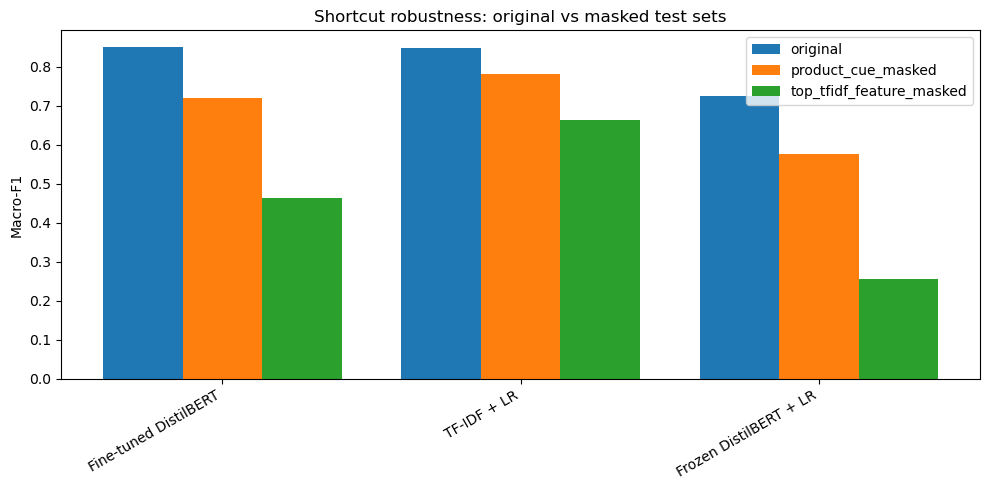

In [34]:
pivot_f1 = robustness_df.pivot(
    index="model", columns="split", values="macro_f1"
).reset_index()
if "original" in pivot_f1.columns:
    for col in ["product_cue_masked", "top_tfidf_feature_masked"]:
        if col in pivot_f1.columns:
            pivot_f1[f"drop_{col}"] = pivot_f1["original"] - pivot_f1[col]

pivot_f1 = pivot_f1.sort_values("original", ascending=False)
pivot_f1.to_csv(Path(cfg.ARTIFACT_DIR) / "robustness_results_wide.csv", index=False)
display(pivot_f1)

plt.figure(figsize=(10, 5))
models = pivot_f1["model"].tolist()
conditions = [
    c
    for c in ["original", "product_cue_masked", "top_tfidf_feature_masked"]
    if c in pivot_f1.columns
]
x = np.arange(len(models))
width = 0.8 / len(conditions)
for i, cond in enumerate(conditions):
    plt.bar(x + i * width, pivot_f1[cond].values, width=width, label=cond)
plt.xticks(x + width * (len(conditions) - 1) / 2, models, rotation=30, ha="right")
plt.ylabel("Macro-F1")
plt.title("Shortcut robustness: original vs masked test sets")
plt.legend()
plt.tight_layout()
plt.savefig(Path(cfg.ARTIFACT_DIR) / "robustness_macro_f1_bar.png", dpi=200)
plt.show()

## 10. Ablation study: transformer max length

**Problem.** If the transformer helps, it is useful to know whether the gain comes partly from reading longer complaint narratives.

This ablation is disabled by default because it is computationally expensive. You can set `RUN_MAX_LENGTH_ABLATION = True` to repeat our results.


In [35]:
RUN_MAX_LENGTH_ABLATION = True
MAX_LENGTH_ABLATIONS = [128, 256]
ablation_rows = []

if TRANSFORMERS_AVAILABLE and RUN_MAX_LENGTH_ABLATION:
    for max_len in MAX_LENGTH_ABLATIONS:
        print(f"Running max_length ablation: {max_len}")
        ab_model, ab_tokenizer, ab_hist = train_distilbert_classifier(
            max_length=max_len
        )
        logits, proba, pred = run_transformer_inference(
            ab_model,
            ab_tokenizer,
            test_texts,
            batch_size=cfg.FT_BATCH_SIZE * 2,
            max_length=max_len,
        )
        row = evaluate_predictions(
            y_test, pred, proba, f"Fine-tuned DistilBERT max_len={max_len}", "test"
        )
        row["max_length"] = max_len
        ablation_rows.append(row)

if ablation_rows:
    ablation_df = pd.DataFrame(ablation_rows)
    ablation_df.to_csv(
        Path(cfg.ARTIFACT_DIR) / "max_length_ablation_results.csv", index=False
    )
    display(ablation_df)
else:
    print("Max-length ablation skipped. Set RUN_MAX_LENGTH_ABLATION=True to run.")

Running max_length ablation: 128


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'epoch': 1, 'train_loss': 0.9806504259204684, 'val_accuracy': 0.8211111111111111, 'val_macro_f1': 0.8203436125271061}
{'epoch': 2, 'train_loss': 0.44174878435216475, 'val_accuracy': 0.8555555555555555, 'val_macro_f1': 0.8549298441452008}
{'epoch': 3, 'train_loss': 0.3139253800642808, 'val_accuracy': 0.8655555555555555, 'val_macro_f1': 0.8653943182069426}
Running max_length ablation: 256


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'epoch': 1, 'train_loss': 0.8941418292291264, 'val_accuracy': 0.8444444444444444, 'val_macro_f1': 0.8443758720045679}
{'epoch': 2, 'train_loss': 0.39811548958939746, 'val_accuracy': 0.8566666666666667, 'val_macro_f1': 0.8557723411151695}
{'epoch': 3, 'train_loss': 0.27358588746292056, 'val_accuracy': 0.8644444444444445, 'val_macro_f1': 0.8640902390723116}


,model,split,accuracy,macro_f1,weighted_f1,mean_confidence,max_length
0,Fine-tuned DistilBERT max_len=128,test,0.832222,0.831933,0.831933,0.888441,128
1,Fine-tuned DistilBERT max_len=256,test,0.860000,0.860361,0.860361,0.901357,256


## 11. Calibration and selective prediction

**Problem.** In a practical triage setting, the model should not be forced to classify every complaint. Low-confidence cases can be sent to manual review.

This section computes Expected Calibration Error (ECE) and selective-prediction curves. Selective prediction keeps only examples above a confidence threshold and measures accuracy and macro-F1 on the retained subset.


In [45]:
def expected_calibration_error(y_true, y_proba, n_bins=10):
    confidences = y_proba.max(axis=1)
    predictions = y_proba.argmax(axis=1)
    correctness = (predictions == y_true).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        in_bin = (confidences > lo) & (confidences <= hi)
        if in_bin.sum() == 0:
            continue
        bin_acc = correctness[in_bin].mean()
        bin_conf = confidences[in_bin].mean()
        ece += in_bin.mean() * abs(bin_acc - bin_conf)
    return float(ece)


def reliability_table(y_true, y_proba, n_bins=10):
    confidences = y_proba.max(axis=1)
    predictions = y_proba.argmax(axis=1)
    correctness = (predictions == y_true).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    rows = []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        in_bin = (confidences > lo) & (confidences <= hi)
        if in_bin.sum() == 0:
            rows.append(
                {
                    "bin_left": lo,
                    "bin_right": hi,
                    "count": 0,
                    "accuracy": np.nan,
                    "confidence": np.nan,
                }
            )
        else:
            rows.append(
                {
                    "bin_left": lo,
                    "bin_right": hi,
                    "count": int(in_bin.sum()),
                    "accuracy": correctness[in_bin].mean(),
                    "confidence": confidences[in_bin].mean(),
                }
            )
    return pd.DataFrame(rows)


def selective_prediction_curve(y_true, y_proba, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.0, 0.99, 50)
    confidences = y_proba.max(axis=1)
    predictions = y_proba.argmax(axis=1)
    rows = []
    for threshold in thresholds:
        keep = confidences >= threshold
        if keep.sum() == 0:
            rows.append(
                {
                    "threshold": threshold,
                    "coverage": 0.0,
                    "accuracy": np.nan,
                    "macro_f1": np.nan,
                    "n_kept": 0,
                }
            )
        else:
            rows.append(
                {
                    "threshold": threshold,
                    "coverage": keep.mean(),
                    "accuracy": accuracy_score(y_true[keep], predictions[keep]),
                    "macro_f1": f1_score(
                        y_true[keep], predictions[keep], average="macro"
                    ),
                    "n_kept": int(keep.sum()),
                }
            )
    return pd.DataFrame(rows)


calibration_rows = []
selective_rows = []

for model_name, bundle in model_registry.items():
    print(f"Calibration for: {model_name}")
    proba = bundle["predict_proba"](test_texts)
    pred = proba.argmax(axis=1)
    ece = expected_calibration_error(y_test, proba)
    calibration_rows.append(
        {
            "model": model_name,
            "ece": ece,
            "mean_confidence": float(proba.max(axis=1).mean()),
            "accuracy": accuracy_score(y_test, pred),
            "macro_f1": f1_score(y_test, pred, average="macro"),
        }
    )
    rel = reliability_table(y_test, proba)
    rel["model"] = model_name
    rel.to_csv(
        Path(cfg.ARTIFACT_DIR)
        / f"reliability_{model_name.replace(' ', '_').replace('+', 'plus')}.csv",
        index=False,
    )
    curve = selective_prediction_curve(y_test, proba)
    curve["model"] = model_name
    selective_rows.append(curve)

calibration_df = pd.DataFrame(calibration_rows).sort_values("ece")
selective_df = (
    pd.concat(selective_rows, ignore_index=True) if selective_rows else pd.DataFrame()
)
calibration_df.to_csv(Path(cfg.ARTIFACT_DIR) / "calibration_summary.csv", index=False)
selective_df.to_csv(
    Path(cfg.ARTIFACT_DIR) / "selective_prediction_curves.csv", index=False
)
display(calibration_df)
display(selective_df.head())

Calibration for: TF-IDF + LR
Calibration for: Frozen DistilBERT + LR
Calibration for: Fine-tuned DistilBERT


,model,ece,mean_confidence,accuracy,macro_f1
2,Fine-tuned DistilBERT,0.043362,0.894473,0.851111,0.850699
0,TF-IDF + LR,0.087066,0.760712,0.847778,0.847883
1,Frozen DistilBERT + LR,0.207325,0.931769,0.724444,0.725724


,threshold,coverage,accuracy,macro_f1,n_kept,model
0,0.000000,1.0,0.847778,0.847883,900,TF-IDF + LR
1,0.020204,1.0,0.847778,0.847883,900,TF-IDF + LR
2,0.040408,1.0,0.847778,0.847883,900,TF-IDF + LR
3,0.060612,1.0,0.847778,0.847883,900,TF-IDF + LR
4,0.080816,1.0,0.847778,0.847883,900,TF-IDF + LR


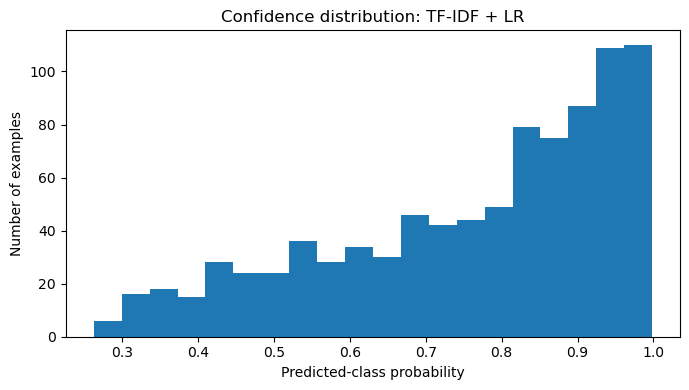

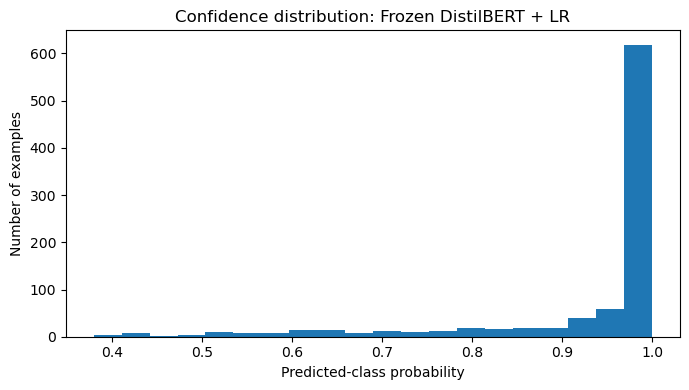

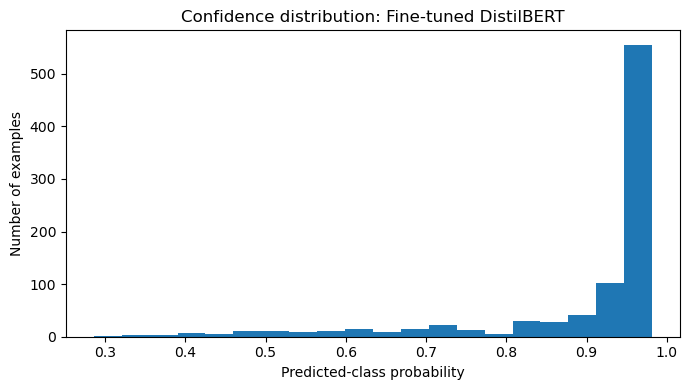

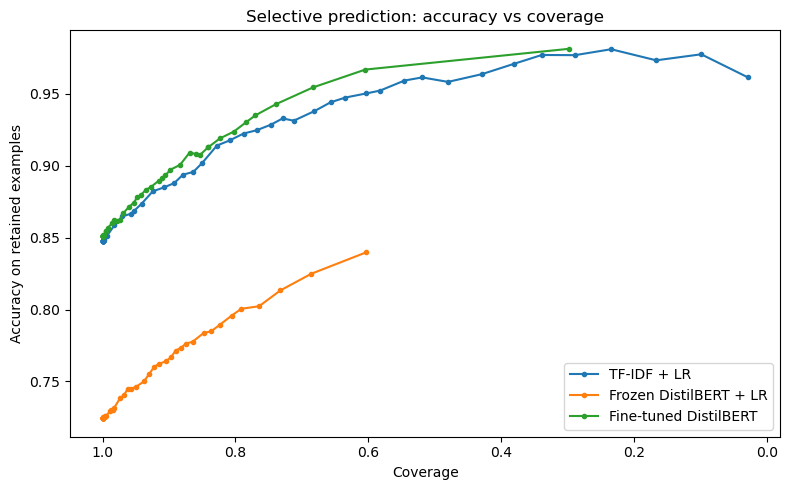

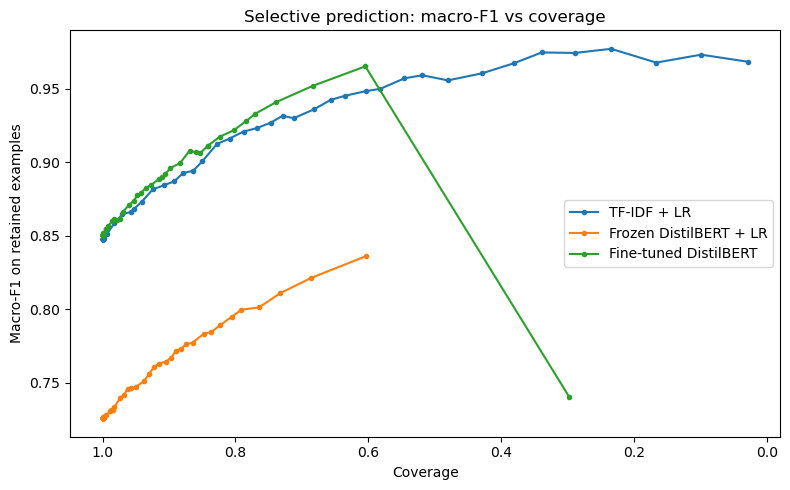

In [46]:
for model_name, bundle in model_registry.items():
    proba = bundle["predict_proba"](test_texts)
    conf = proba.max(axis=1)
    plt.figure(figsize=(7, 4))
    plt.hist(conf, bins=20)
    plt.title(f"Confidence distribution: {model_name}")
    plt.xlabel("Predicted-class probability")
    plt.ylabel("Number of examples")
    plt.tight_layout()
    fname = f"confidence_hist_{model_name.replace(' ', '_').replace('+', 'plus')}.png"
    plt.savefig(Path(cfg.ARTIFACT_DIR) / fname, dpi=200)
    plt.show()

if not selective_df.empty:
    plt.figure(figsize=(8, 5))
    for model_name in selective_df["model"].unique():
        part = selective_df[selective_df["model"] == model_name].dropna(
            subset=["accuracy"]
        )
        plt.plot(
            part["coverage"],
            part["accuracy"],
            marker="o",
            markersize=3,
            label=model_name,
        )
    plt.xlabel("Coverage")
    plt.ylabel("Accuracy on retained examples")
    plt.title("Selective prediction: accuracy vs coverage")
    plt.gca().invert_xaxis()
    plt.legend()
    plt.tight_layout()
    plt.savefig(Path(cfg.ARTIFACT_DIR) / "selective_accuracy_vs_coverage.png", dpi=200)
    plt.show()

    plt.figure(figsize=(8, 5))
    for model_name in selective_df["model"].unique():
        part = selective_df[selective_df["model"] == model_name].dropna(
            subset=["macro_f1"]
        )
        plt.plot(
            part["coverage"],
            part["macro_f1"],
            marker="o",
            markersize=3,
            label=model_name,
        )
    plt.xlabel("Coverage")
    plt.ylabel("Macro-F1 on retained examples")
    plt.title("Selective prediction: macro-F1 vs coverage")
    plt.gca().invert_xaxis()
    plt.legend()
    plt.tight_layout()
    plt.savefig(Path(cfg.ARTIFACT_DIR) / "selective_macro_f1_vs_coverage.png", dpi=200)
    plt.show()

## 12. Retrieval-based evidence analysis

**Problem.** A predicted label is easier to trust when similar historical complaints support it. A prediction is riskier when the nearest neighbors mostly belong to different classes.

For each test complaint, this section retrieves the top 5 most similar training complaints using TF-IDF cosine similarity. We define **retrieval support** as the fraction of retrieved neighbors whose true label matches the model prediction, then relate this support score to accuracy.


In [47]:
retrieval_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=80_000,
    sublinear_tf=True,
)
X_train_ret = retrieval_vectorizer.fit_transform(train_texts)
X_test_ret = retrieval_vectorizer.transform(test_texts)

nn = NearestNeighbors(n_neighbors=cfg.RETRIEVAL_K, metric="cosine", algorithm="brute")
nn.fit(X_train_ret)
distances, indices = nn.kneighbors(X_test_ret, return_distance=True)


def retrieval_support_for_predictions(pred, neighbor_indices, train_labels):
    supports = []
    for i in range(len(pred)):
        neighbor_labels = train_labels[neighbor_indices[i]]
        supports.append(float(np.mean(neighbor_labels == pred[i])))
    return np.array(supports)


retrieval_rows = []
for model_name, bundle in model_registry.items():
    proba = bundle["predict_proba"](test_texts)
    pred = proba.argmax(axis=1)
    support = retrieval_support_for_predictions(pred, indices, y_train)
    correct = (pred == y_test).astype(int)
    for i in range(len(test_texts)):
        retrieval_rows.append(
            {
                "model": model_name,
                "test_index": i,
                "true_label": id_to_label[int(y_test[i])],
                "pred_label": id_to_label[int(pred[i])],
                "confidence": float(proba[i].max()),
                "correct": int(correct[i]),
                "retrieval_support": float(support[i]),
                "text": test_texts[i],
            }
        )

retrieval_support_df = pd.DataFrame(retrieval_rows)
retrieval_support_df.to_csv(
    Path(cfg.ARTIFACT_DIR) / "retrieval_support_by_example.csv", index=False
)
display(retrieval_support_df.head())

,model,test_index,true_label,pred_label,confidence,correct,retrieval_support,text
0,TF-IDF + LR,0,Debt collection,Debt collection,0.845631,1,0.8,I have a debt with an apartment community and had called the agency listed on my credit report. They told me that the account had been transferred to an alleged law firm. I att...
1,TF-IDF + LR,1,Debt collection,Credit reporting,0.577561,0,0.6,I have several accounts that are listed with this company that is a result of my identity being stolen and are fraudulent I have submitted an ftc report # XXXX and a police rep...
2,TF-IDF + LR,2,Credit reporting,Credit reporting,0.988180,1,0.8,Equifax will not correct errors that they placed on my credit report. I have XXXX Student Loans XXXX (Account XXXX). Equifax is reporting that I have XXXX loans. A few weeks ag...
3,TF-IDF + LR,3,Bank account or service,Bank account or service,0.940774,1,1.0,"To whom it may concern, I have been a loyal customer at Wells Fargo since XX/XX/XXXX. On XXXX XXXX, XXXX, I deposited a personal check from my wife 's account in the amount of ..."
4,TF-IDF + LR,4,Credit card,Credit card,0.682791,1,1.0,"On Friday, XXXX XXXX, 2015, I called the phone number on the back of the XXXX XXXX XXXX XXXX issued by Barclays Bank Delaware to determine if our family 's checked bags on a fo..."


,support_bin,n,accuracy,mean_confidence,model
0,"(-0.001, 0.167]",38,0.394737,0.515110,TF-IDF + LR
1,"(0.167, 0.333]",60,0.566667,0.554029,TF-IDF + LR
2,"(0.333, 0.5]",123,0.691057,0.649686,TF-IDF + LR
3,"(0.5, 0.667]",184,0.869565,0.724914,TF-IDF + LR
4,"(0.667, 0.833]",217,0.926267,0.806873,TF-IDF + LR
5,"(0.833, 1.0]",278,0.964029,0.875674,TF-IDF + LR
6,"(-0.001, 0.167]",110,0.172727,0.823178,Frozen DistilBERT + LR
7,"(0.167, 0.333]",97,0.237113,0.868801,Frozen DistilBERT + LR
8,"(0.333, 0.5]",113,0.628319,0.921915,Frozen DistilBERT + LR
9,"(0.5, 0.667]",151,0.854305,0.954098,Frozen DistilBERT + LR


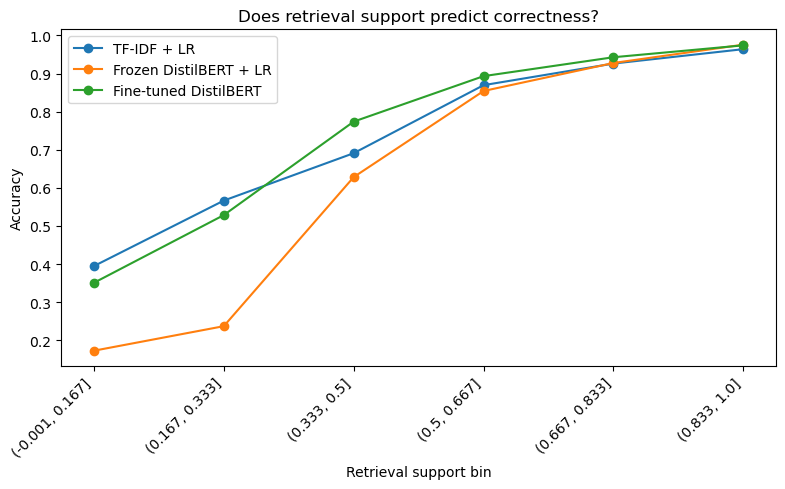

In [48]:
support_bins = np.linspace(0, 1, cfg.RETRIEVAL_K + 2)
binned_rows = []
for model_name in retrieval_support_df["model"].unique():
    part = retrieval_support_df[retrieval_support_df["model"] == model_name].copy()
    part["support_bin"] = pd.cut(
        part["retrieval_support"], bins=support_bins, include_lowest=True
    )
    grouped = (
        part.groupby("support_bin")
        .agg(
            n=("correct", "size"),
            accuracy=("correct", "mean"),
            mean_confidence=("confidence", "mean"),
        )
        .reset_index()
    )
    grouped["model"] = model_name
    binned_rows.append(grouped)

retrieval_binned_df = pd.concat(binned_rows, ignore_index=True)
retrieval_binned_df.to_csv(
    Path(cfg.ARTIFACT_DIR) / "retrieval_support_binned_accuracy.csv", index=False
)
display(retrieval_binned_df)

plt.figure(figsize=(8, 5))
for model_name in retrieval_support_df["model"].unique():
    part = retrieval_binned_df[retrieval_binned_df["model"] == model_name]
    x = np.arange(len(part))
    plt.plot(x, part["accuracy"], marker="o", label=model_name)
plt.xticks(
    np.arange(len(part)), [str(x) for x in part["support_bin"]], rotation=45, ha="right"
)
plt.ylabel("Accuracy")
plt.xlabel("Retrieval support bin")
plt.title("Does retrieval support predict correctness?")
plt.legend()
plt.tight_layout()
plt.savefig(Path(cfg.ARTIFACT_DIR) / "retrieval_support_vs_accuracy.png", dpi=200)
plt.show()

In [49]:
def build_retrieval_demo_examples(model_name, n_examples=8):
    bundle = model_registry[model_name]
    proba = bundle["predict_proba"](test_texts)
    pred = proba.argmax(axis=1)
    correct = pred == y_test
    support = retrieval_support_for_predictions(pred, indices, y_train)

    ranking = pd.DataFrame(
        {
            "test_index": np.arange(len(test_texts)),
            "confidence": proba.max(axis=1),
            "correct": correct.astype(int),
            "retrieval_support": support,
        }
    )
    ranking["interesting_score"] = (
        (1 - ranking["correct"]) * 3
        + ranking["confidence"]
        + (1 - ranking["retrieval_support"])
    )
    chosen = (
        ranking.sort_values("interesting_score", ascending=False)
        .head(n_examples)["test_index"]
        .tolist()
    )

    rows = []
    for i in chosen:
        neighbor_strs = []
        for rank, j in enumerate(indices[i], start=1):
            neighbor_strs.append(
                f"{rank}. label={id_to_label[int(y_train[j])]}, dist={distances[i][rank-1]:.3f}, text={train_texts[j][:250]}"
            )
        rows.append(
            {
                "model": model_name,
                "test_index": int(i),
                "true_label": id_to_label[int(y_test[i])],
                "pred_label": id_to_label[int(pred[i])],
                "confidence": float(proba[i].max()),
                "correct": bool(correct[i]),
                "retrieval_support": float(support[i]),
                "text": test_texts[i],
                "retrieved_neighbors": "\n".join(neighbor_strs),
            }
        )
    return pd.DataFrame(rows)


demo_model_name = (
    "Fine-tuned DistilBERT"
    if "Fine-tuned DistilBERT" in model_registry
    else "TF-IDF + LR"
)
demo_examples_df = build_retrieval_demo_examples(demo_model_name, n_examples=10)
demo_examples_df.to_csv(
    Path(cfg.ARTIFACT_DIR) / "retrieval_demo_examples.csv", index=False
)
display(
    demo_examples_df[
        [
            "model",
            "true_label",
            "pred_label",
            "confidence",
            "correct",
            "retrieval_support",
            "text",
            "retrieved_neighbors",
        ]
    ].head(5)
)

,model,true_label,pred_label,confidence,correct,retrieval_support,text,retrieved_neighbors
0,Fine-tuned DistilBERT,Credit reporting,Bank account or service,0.968301,False,0.0,To whom it may concern : I attempted a Second Chance Bank Account at XXXX XXXX XXXX yesterday in Michigan and the teller was unable to proceed due to the Fraud Alert based on m...,"1. label=Credit reporting, dist=0.863, text=One of my addresses is listed at XXXX XXXX XXXX, XXXX XXXX XXXX. Year it is listred for I was XXXX at XXXX XXXX XXXX in XXXX.\n2. la..."
1,Fine-tuned DistilBERT,Credit card,Bank account or service,0.958943,False,0.0,Capitol one has removed 100 $ on XXXX separate occassions in the last two months from my bank account without my permission. I reviewed my capitol one account online and nowher...,"1. label=Mortgage, dist=0.883, text=Seterus Inc.took {$5000.00} out of my checking account without my permission. This occurred on XXXX XXXX 2015.\n2. label=Credit card, dist=0..."
2,Fine-tuned DistilBERT,Credit reporting,Debt collection,0.958217,False,0.0,"First off, thank you so much for helping me. My Cell is XXXX I have a pre-trial appointment XXXX/XXXX/2015 @ XXXX XXXX XXXX XXXX XXXX XXXX. I would have gladly settled or paid ...","1. label=Credit reporting, dist=0.843, text=Other Debt : $ XXXX only owe XXXX {$9000.00} {$8900.00} ( - {$36.00} ) XXXXI only owe XXXX currently\n2. label=Credit reporting, dis..."
3,Fine-tuned DistilBERT,Credit reporting,Debt collection,0.950480,False,0.0,"I have a public record due to common law. This debt was created without knowledge, but was paid in full to clear my credit.","1. label=Credit reporting, dist=0.684, text=bankruptcy public record and some information that is not belong to me\n2. label=Credit reporting, dist=0.801, text=There is a publi..."
4,Fine-tuned DistilBERT,Mortgage,Debt collection,0.948320,False,0.0,"Although I received a letter from Green Tree ( see attached ) saying that all calls on this account have been stopped, I received a call at my work on XXXX/XXXX/15 at XXXX. Thi...","1. label=Mortgage, dist=0.801, text=I, XXXX XXXX XXXX, am a customer of Green Tree Servicing with account number XXXX. On XXXX XXXX, 2015, l summited the letter to request the ..."


## 13. Comparative error analysis

**Problem.** Aggregate scores do not show which examples each model actually fixes or breaks.

This section compares model predictions example by example. It exports cases where both models are correct, both are wrong, only TF-IDF is correct, or only fine-tuned DistilBERT is correct. These examples are useful for the qualitative discussion in the report and presentation.


In [50]:
error_rows = []

tfidf_proba = model_registry["TF-IDF + LR"]["predict_proba"](test_texts)
tfidf_pred = tfidf_proba.argmax(axis=1)
comparison_model_name = (
    "Fine-tuned DistilBERT"
    if "Fine-tuned DistilBERT" in model_registry
    else (
        "Frozen DistilBERT + LR"
        if "Frozen DistilBERT + LR" in model_registry
        else "TF-IDF + LR"
    )
)
comparison_proba = model_registry[comparison_model_name]["predict_proba"](test_texts)
comparison_pred = comparison_proba.argmax(axis=1)

tfidf_product_masked_pred = robustness_predictions.get(
    ("TF-IDF + LR", "product_cue_masked"), {}
).get("pred", None)
comparison_product_masked_pred = robustness_predictions.get(
    (comparison_model_name, "product_cue_masked"), {}
).get("pred", None)

for i, text in enumerate(test_texts):
    row = {
        "test_index": i,
        "true_label": id_to_label[int(y_test[i])],
        "tfidf_pred": id_to_label[int(tfidf_pred[i])],
        "tfidf_conf": float(tfidf_proba[i].max()),
        f"{comparison_model_name}_pred": id_to_label[int(comparison_pred[i])],
        f"{comparison_model_name}_conf": float(comparison_proba[i].max()),
        "tfidf_correct": bool(tfidf_pred[i] == y_test[i]),
        f"{comparison_model_name}_correct": bool(comparison_pred[i] == y_test[i]),
        "text": text,
    }
    if tfidf_product_masked_pred is not None:
        row["tfidf_product_masked_pred"] = id_to_label[
            int(tfidf_product_masked_pred[i])
        ]
        row["tfidf_flipped_after_product_masking"] = bool(
            tfidf_product_masked_pred[i] != tfidf_pred[i]
        )
    if comparison_product_masked_pred is not None:
        row[f"{comparison_model_name}_product_masked_pred"] = id_to_label[
            int(comparison_product_masked_pred[i])
        ]
        row[f"{comparison_model_name}_flipped_after_product_masking"] = bool(
            comparison_product_masked_pred[i] != comparison_pred[i]
        )

    if (tfidf_pred[i] != y_test[i]) and (comparison_pred[i] == y_test[i]):
        row["case_type"] = "tfidf_wrong_comparison_right"
    elif (tfidf_pred[i] == y_test[i]) and (comparison_pred[i] != y_test[i]):
        row["case_type"] = "tfidf_right_comparison_wrong"
    elif (tfidf_pred[i] != y_test[i]) and (comparison_pred[i] != y_test[i]):
        row["case_type"] = "both_wrong"
    else:
        row["case_type"] = "both_right"
    error_rows.append(row)

error_analysis_df = pd.DataFrame(error_rows)
error_analysis_df.to_csv(
    Path(cfg.ARTIFACT_DIR) / "comparative_error_analysis.csv", index=False
)
display(error_analysis_df["case_type"].value_counts().to_frame("count"))
display(error_analysis_df[error_analysis_df["case_type"] != "both_right"].head(10))

,count
case_type,
both_right,720
both_wrong,91
tfidf_wrong_comparison_right,46
tfidf_right_comparison_wrong,43


,test_index,true_label,tfidf_pred,tfidf_conf,Fine-tuned DistilBERT_pred,Fine-tuned DistilBERT_conf,tfidf_correct,Fine-tuned DistilBERT_correct,text,tfidf_product_masked_pred,tfidf_flipped_after_product_masking,Fine-tuned DistilBERT_product_masked_pred,Fine-tuned DistilBERT_flipped_after_product_masking,case_type
1,1,Debt collection,Credit reporting,0.577561,Debt collection,0.431297,False,True,I have several accounts that are listed with this company that is a result of my identity being stolen and are fraudulent I have submitted an ftc report # XXXX and a police rep...,Credit reporting,False,Debt collection,False,tfidf_wrong_comparison_right
9,9,Bank account or service,Bank account or service,0.355314,Credit card,0.841168,True,False,"It 's happened so weird, so I only ask the bank online to increase my credit line for information but not request. And then the bank send me notice and did n't ask my authoriza...",Bank account or service,False,Credit card,False,tfidf_right_comparison_wrong
10,10,Credit card,Debt collection,0.740466,Debt collection,0.890142,False,False,We received a debt notice from a collection agency related to a XXXX we had applied for but did not receive indicating that we owed {$250.00} which should be mailed to them. We...,Credit reporting,True,Debt collection,False,both_wrong
12,12,Debt collection,Credit card,0.296215,Debt collection,0.849808,False,True,"I had a XXXX service and i finished the contract before time. They have a 2 years contact. I had to finish my service because first of all they lie to me about pricing, and the...",Credit card,False,Debt collection,False,tfidf_wrong_comparison_right
13,13,Credit card,Debt collection,0.950435,Debt collection,0.951168,False,False,"Portfolio Recovery Corp ( PRC ) continues to call on a stale debt 2006, which was discharged. They were notified XXXX in the past about this",Debt collection,False,Debt collection,False,both_wrong
16,16,Credit card,Bank account or service,0.527450,Bank account or service,0.824812,False,False,I signed up for a XXXX through TD Bank under promotional terms. The offer was a {$200.00} cash rewards bonus reflected on the account in 6-8 weeks after spending {$1500.00} in ...,Bank account or service,False,Bank account or service,False,both_wrong
17,17,Credit card,Mortgage,0.419834,Debt collection,0.512235,False,False,"Back in XX/XX/XXXX, I applied and received a care credit account for XXXX worth of dental work my husband needed. Our insurance would only cover XXXX of this amount. On the las...",Debt collection,True,Debt collection,False,both_wrong
22,22,Debt collection,Credit reporting,0.771668,Debt collection,0.619383,False,True,"Ftc case # XXXX, XXXX/XXXX/2008 states that reporting of tribute XXXX ( compu credit ) by XXXX party collections is prohibited. I have sent this documentation and a request for...",Credit reporting,False,Debt collection,False,tfidf_wrong_comparison_right
32,32,Debt collection,Debt collection,0.485894,Mortgage,0.468784,True,False,I received a call from a company stating that I had XXXX outstanding payday loans from 2011. I was told that I had taken out an online payday loan in the amount of {$400.00} on...,Debt collection,False,Mortgage,False,tfidf_right_comparison_wrong
37,37,Credit card,Credit card,0.742331,Bank account or service,0.708247,True,False,"This company made me a Video DVD, but never got back with me to edit the DVD. What I wanted in this DVD was to have Pictures of Women 's shoes, of the actual items I was sellin...",Credit card,False,Bank account or service,False,tfidf_right_comparison_wrong


In [51]:
report_error_examples = []
for case_type in [
    "tfidf_wrong_comparison_right",
    "tfidf_right_comparison_wrong",
    "both_wrong",
]:
    part = error_analysis_df[error_analysis_df["case_type"] == case_type].copy()
    if len(part) == 0:
        continue
    part["max_conf"] = part[["tfidf_conf", f"{comparison_model_name}_conf"]].max(axis=1)
    report_error_examples.append(part.sort_values("max_conf", ascending=False).head(5))

report_error_examples_df = (
    pd.concat(report_error_examples, ignore_index=True)
    if report_error_examples
    else pd.DataFrame()
)
report_error_examples_df.to_csv(
    Path(cfg.ARTIFACT_DIR) / "report_error_examples_selected.csv", index=False
)
display(report_error_examples_df.head(15))

,test_index,true_label,tfidf_pred,tfidf_conf,Fine-tuned DistilBERT_pred,Fine-tuned DistilBERT_conf,tfidf_correct,Fine-tuned DistilBERT_correct,text,tfidf_product_masked_pred,tfidf_flipped_after_product_masking,Fine-tuned DistilBERT_product_masked_pred,Fine-tuned DistilBERT_flipped_after_product_masking,case_type,max_conf
0,412,Credit reporting,Debt collection,0.511137,Credit reporting,0.972999,False,True,Experian has listed on my credit report a debt that was abolished by XXXX XXXX in XXXX 2013. This was a joint account as I co-signed for a coworker to purchase a used car. XXXX...,Debt collection,False,Credit reporting,False,tfidf_wrong_comparison_right,0.972999
1,394,Mortgage,Bank account or service,0.420296,Mortgage,0.967630,False,True,Dear President of MB Financial. \nPlease be advised that my subject loan # was tagged with a 30-60 late for no reason on XXXX 2015. \nThe XXXX check was deposit XXXX check # XX...,Bank account or service,False,Credit card,True,tfidf_wrong_comparison_right,0.967630
2,266,Debt collection,Credit reporting,0.408390,Debt collection,0.954565,False,True,I have no idea where this debt has come from. I have never opened an account with XXXX Anyone Can use your name to open an account if they have colllected your personal informa...,Bank account or service,True,Debt collection,False,tfidf_wrong_comparison_right,0.954565
3,815,Credit reporting,Credit card,0.886120,Credit reporting,0.942681,False,True,"my credit report is skewed because of the amount of money owed related to the credit limit. \nI have a XXXX credit card, that had a credit limit of {$13000.00} in 2014. They re...",Credit card,False,Credit card,True,tfidf_wrong_comparison_right,0.942681
4,312,Credit card,Bank account or service,0.454284,Credit card,0.941688,False,True,"I contracted with XXXX XXXX XXXX in XXXX, XXXX to conduct my move from XXXX to XXXX, XXXX. I paid for the entire move, over {$8000.00} on a Merrill Lynch, XXXX card which is ow...",Bank account or service,False,Bank account or service,True,tfidf_wrong_comparison_right,0.941688
5,495,Credit reporting,Credit reporting,0.568953,Bank account or service,0.968301,True,False,To whom it may concern : I attempted a Second Chance Bank Account at XXXX XXXX XXXX yesterday in Michigan and the teller was unable to proceed due to the Fraud Alert based on m...,Credit reporting,False,Bank account or service,False,tfidf_right_comparison_wrong,0.968301
6,389,Bank account or service,Bank account or service,0.601040,Credit card,0.951687,True,False,"Originally, I had linked my Chase credit card to my Chase checking account since they informed me that this would be convenient in case I get overdrafted on certain bills I hav...",Bank account or service,False,Credit card,False,tfidf_right_comparison_wrong,0.951687
7,778,Debt collection,Debt collection,0.432822,Bank account or service,0.944872,True,False,Northland group called me and I set up payment arrangements. For 3 years they have been taking money out of my account. In XXXX XXXX they told me my payment arrangement had ran...,Debt collection,False,Bank account or service,False,tfidf_right_comparison_wrong,0.944872
8,264,Bank account or service,Bank account or service,0.585781,Credit card,0.925097,True,False,Thank you for submitting an Online Consumer Complaint. A representative from the Consumer Services Office may contact youto follow up. \n\nHere is a copy of the information you...,Bank account or service,False,Bank account or service,True,tfidf_right_comparison_wrong,0.925097
9,199,Credit card,Credit card,0.857947,Credit reporting,0.910688,True,False,This company XXXX I have had for close to 3 years. I was able to see my report when I pulled my credit on XXXX. Sometime in XX/XX/XXXX this credit card company reported the acc...,Credit card,False,Credit reporting,False,tfidf_right_comparison_wrong,0.910688


## 14. Attention inspection for fine-tuned DistilBERT

**Problem.** Attention weights are not a full explanation, but they can provide a quick qualitative check of which tokens the fine-tuned transformer emphasizes.

This section inspects attention for selected texts.


In [52]:
def inspect_attention_for_text(text, layer=-1, top_k=20):
    if not (
        TRANSFORMERS_AVAILABLE and ft_model is not None and ft_tokenizer is not None
    ):
        print("Fine-tuned transformer is not available.")
        return None
    ft_model.eval()
    enc = ft_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=False,
        max_length=cfg.MAX_LENGTH,
    )
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        out = ft_model(**enc, output_attentions=True)
    if out.attentions is None:
        print("No attentions returned.")
        return None
    tokens = ft_tokenizer.convert_ids_to_tokens(
        enc["input_ids"][0].detach().cpu().tolist()
    )
    att = out.attentions[layer][0].detach().cpu().numpy()  # [heads, seq, seq]
    received = att.mean(axis=0).mean(axis=0)
    rows = pd.DataFrame({"token": tokens, "attention_received": received})
    return rows.sort_values("attention_received", ascending=False).head(top_k)


if "Fine-tuned DistilBERT" in model_registry:
    attention_df = inspect_attention_for_text(test_texts[0])
    display(attention_df)
else:
    print("Fine-tuned model unavailable; skipping attention inspection.")

,token,attention_received
154,.,0.109960
87,.,0.047720
78,",",0.045746
34,.,0.038148
255,[SEP],0.037249
212,.,0.021525
160,",",0.020273
108,debt,0.015103
18,report,0.015030
0,[CLS],0.014611


## 15. Final artifact export

This section saves outputs to `artifacts_final/`.


In [53]:
with open(Path(cfg.ARTIFACT_DIR) / "config.json", "w") as f:
    json.dump(asdict(cfg), f, indent=2, default=str)
with open(Path(cfg.ARTIFACT_DIR) / "label_mapping.json", "w") as f:
    json.dump({str(k): v for k, v in id_to_label.items()}, f, indent=2)
pd.DataFrame(all_results).to_csv(
    Path(cfg.ARTIFACT_DIR) / "all_standard_results.csv", index=False
)

summary_lines = []
summary_lines.append("# Final Project Results Summary\n")
summary_lines.append("## Standard performance\n")
summary_lines.append(pd.DataFrame(all_results).to_markdown(index=False))
summary_lines.append("\n\n## Robustness results\n")
summary_lines.append(
    pivot_f1.to_markdown(index=False)
    if "pivot_f1" in globals()
    else "Robustness table not available."
)
summary_lines.append("\n\n## Calibration summary\n")
summary_lines.append(
    calibration_df.to_markdown(index=False)
    if "calibration_df" in globals()
    else "Calibration table not available."
)
summary_lines.append("\n\n## Retrieval support summary\n")
summary_lines.append(
    retrieval_binned_df.to_markdown(index=False)
    if "retrieval_binned_df" in globals()
    else "Retrieval table not available."
)

with open(Path(cfg.ARTIFACT_DIR) / "final_results_summary.md", "w") as f:
    f.write("\n".join(summary_lines))

print("Artifacts written to:", Path(cfg.ARTIFACT_DIR).resolve())
for p in sorted(Path(cfg.ARTIFACT_DIR).glob("*")):
    print(" -", p.name)

Artifacts written to: /Users/maksimpetrenko/Desktop/final_project 2/artifacts_final
 - all_standard_results.csv
 - calibration_summary.csv
 - class_counts.png
 - comparative_error_analysis.csv
 - confidence_hist_Fine-tuned_DistilBERT.png
 - confidence_hist_Frozen_DistilBERT_plus_LR.png
 - confidence_hist_TF-IDF_plus_LR.png
 - config.json
 - confusion_finetuned_distilbert.png
 - confusion_frozen_distilbert_lr.png
 - confusion_tfidf_lr.png
 - distilbert_finetuning_history.csv
 - eda_top_lexical_features_by_class.csv
 - final_results_summary.md
 - label_mapping.json
 - max_length_ablation_results.csv
 - reliability_Fine-tuned_DistilBERT.csv
 - reliability_Frozen_DistilBERT_plus_LR.csv
 - reliability_TF-IDF_plus_LR.csv
 - report_error_examples_selected.csv
 - retrieval_demo_examples.csv
 - retrieval_support_binned_accuracy.csv
 - retrieval_support_by_example.csv
 - retrieval_support_vs_accuracy.png
 - robustness_macro_f1_bar.png
 - robustness_results_long.csv
 - robustness_results_wide.csv

We tried to keep comments in the notebook intentionally concise. Our discussion of the results in detail can be found in the report.